In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "IND"
away= "BRK"

In [3]:
game_day = datetime.strptime("2025-03-02", "%Y-%m-%d")

In [4]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,Tm_PTS,Opp_PTS,MP,Tm_FG,Tm_FGA,...,Tm_TOV%,Opp_AST%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Rest,Opp_Rest,Tm_Pos,Tm_Pace,Opp_Pace
64,IND,PHI,2025-03-14,W,A,112,100,240,44,89,...,10.2,35.1,7.4,16.7,14.9,3.0,2.0,94.408775,94.408775,94.408775
65,IND,MIL,2025-03-15,L,A,119,126,240,46,96,...,10.6,65.1,9.0,7.5,15.8,1.0,2.0,99.594340,99.594340,99.594340
66,IND,MIN,2025-03-17,W,A,132,130,265,48,97,...,15.7,56.8,9.7,11.7,11.7,2.0,1.0,112.876315,102.227606,102.227606
67,IND,DAL,2025-03-19,W,H,135,131,240,45,82,...,10.1,47.9,5.8,0.0,11.3,2.0,3.0,104.000150,104.000150,104.000150
68,IND,BRK,2025-03-20,W,H,105,99,265,35,81,...,20.9,55.6,10.2,8.0,12.8,1.0,2.0,107.567620,97.419731,97.419731


In [5]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,Tm_PTS,Opp_PTS,MP,Tm_FG,Tm_FGA,...,Tm_TOV%,Opp_AST%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Rest,Opp_Rest,Tm_Pos,Tm_Pace,Opp_Pace
64,PHI,IND,2025-03-14,L,H,100,112,240,37,82,...,14.9,70.5,6.4,9.1,10.2,2.0,3.0,94.408775,94.408775,94.408775
65,MIL,IND,2025-03-15,W,H,126,119,240,43,79,...,15.8,63.0,9.0,9.5,10.6,2.0,1.0,99.594340,99.594340,99.594340
66,MIN,IND,2025-03-17,L,H,130,132,265,44,97,...,11.7,58.3,6.2,10.9,15.7,1.0,2.0,112.876315,102.227606,102.227606
67,DAL,IND,2025-03-19,L,A,131,135,240,48,88,...,11.3,64.4,3.8,8.2,10.1,3.0,2.0,104.000150,104.000150,104.000150
68,BRK,IND,2025-03-20,L,A,99,105,265,36,101,...,12.8,51.4,9.3,15.7,20.9,2.0,1.0,107.567620,97.419731,97.419731


In [6]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,Tm_PTS,Opp_PTS,MP,Tm_FG,Tm_FGA,...,Tm_TOV%,Opp_AST%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Rest,Opp_Rest,Tm_Pos,Tm_Pace,Opp_Pace
65,BRK,CHI,2025-03-13,L,A,110,116,240,43,96,...,8.0,58.5,8.5,6.5,7.3,2.0,3.0,94.519105,94.519105,94.519105
66,BRK,BOS,2025-03-15,L,H,113,115,240,42,90,...,8.6,65.9,5.9,15.9,8.0,2.0,1.0,84.185080,84.185080,84.185080
67,BRK,ATL,2025-03-16,W,H,122,114,240,43,90,...,14.5,64.3,11.9,20.0,12.2,1.0,2.0,100.602660,100.602660,100.602660
68,BRK,BOS,2025-03-18,L,A,96,104,240,36,88,...,8.6,68.6,6.4,11.6,12.8,2.0,3.0,94.035320,94.035320,94.035320
69,BRK,IND,2025-03-20,L,A,99,105,265,36,101,...,12.8,51.4,9.3,15.7,20.9,2.0,1.0,107.567620,97.419731,97.419731


In [7]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,Tm_PTS,Opp_PTS,MP,Tm_FG,Tm_FGA,...,Tm_TOV%,Opp_AST%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Rest,Opp_Rest,Tm_Pos,Tm_Pace,Opp_Pace
65,CHI,BRK,2025-03-13,W,H,116,110,240,41,90,...,7.3,74.4,6.3,13.2,8.0,3.0,2.0,94.519105,94.519105,94.519105
66,BOS,BRK,2025-03-15,W,A,115,113,240,44,84,...,8.0,81.0,4.8,6.5,8.6,1.0,2.0,84.185080,84.185080,84.185080
67,ATL,BRK,2025-03-16,L,A,114,122,240,42,90,...,12.2,76.7,7.0,9.4,14.5,2.0,1.0,100.602660,100.602660,100.602660
68,BOS,BRK,2025-03-18,W,H,104,96,240,35,79,...,12.8,58.3,9.6,6.5,8.6,3.0,2.0,94.035320,94.035320,94.035320
69,IND,BRK,2025-03-20,W,H,105,99,265,35,81,...,20.9,55.6,10.2,8.0,12.8,1.0,2.0,107.567620,97.419731,97.419731


In [8]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'Tm_PTS', 'Opp_PTS', 'MP', 'Tm_FG', 'Tm_FGA', 'Tm_FG%', 'Tm_2P', 'Tm_2PA', 'Tm_2P%', 'Tm_3P', 'Tm_3PA', 'Tm_3P%', 'Tm_FT', 'Tm_FTA', 'Tm_FT%', 'Opp_FG', 'Opp_FGA', 'Opp_FG%', 'Opp_2P', 'Opp_2PA', 'Opp_2P%', 'Opp_3P', 'Opp_3PA', 'Opp_3P%', 'Opp_FT', 'Opp_FTA', 'Opp_FT%', 'Tm_ORB', 'Tm_DRB', 'Tm_TRB', 'Opp_ORB', 'Opp_DRB', 'Opp_TRB', 'Tm_AST', 'Tm_STL', 'Tm_BLK', 'Tm_TOV', 'Tm_PF', 'Opp_AST', 'Opp_STL', 'Opp_BLK', 'Opp_TOV', 'Opp_PF', 'Tm_ORtg', 'Tm_DRtg', 'Tm_FTr', 'Tm_3PAr', 'Tm_TS%', 'Tm_eFG%', 'Tm_FT/FGA', 'Opp_ORtg', 'Opp_DRtg', 'Opp_FTr', 'Opp_3PAr', 'Opp_TS%', 'Opp_eFG%', 'Opp_FT/FGA', 'Tm_ORB%', 'Tm_DRB%', 'Tm_TRB%', 'Opp_ORB%', 'Opp_DRB%', 'Opp_TRB%', 'Tm_AST%', 'Tm_STL%', 'Tm_BLK%', 'Tm_TOV%', 'Opp_AST%', 'Opp_STL%', 'Opp_BLK%', 'Opp_TOV%', 'Tm_Rest', 'Opp_Rest', 'Tm_Pos', 'Tm_Pace', 'Opp_Pace']


# Desc

# Features

## Offense

In [9]:
offense= ['Tm_PTS', 'Tm_FGA', 'Tm_FG%', 'Tm_2PA', 'Tm_2P%', 'Tm_3PA', 'Tm_3P%', 'Tm_FTA', 'Tm_FT%', 'Tm_ORB', 'Tm_AST', 'Tm_TOV',
          'Tm_ORtg', 'Tm_FTr', 'Tm_3PAr', 'Tm_TS%', 'Tm_eFG%', 'Tm_FT/FGA', 'Tm_ORB%','Tm_AST%', 'Opp_DRB', 'Opp_STL', 'Opp_BLK', 
          'Opp_DRtg', 'Opp_DRB%', 'Opp_STL%', 'Opp_BLK%', 'Opp_TOV%', 'Tm_Pace']

In [10]:
df_home_off= df_home[offense]
df_home_off.head()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Tm_AST%,Opp_DRB,Opp_STL,Opp_BLK,Opp_DRtg,Opp_DRB%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Pace
0,115,83,0.506,52,0.635,31,0.290,25,0.880,7,...,76.2,26,6,2,116.6,78.8,6.1,3.8,12.2,98.647030
1,98,83,0.494,53,0.717,30,0.100,20,0.650,9,...,68.3,32,5,4,102.5,78.0,5.2,7.5,11.0,95.637000
2,114,84,0.464,52,0.500,32,0.406,34,0.676,7,...,71.8,34,9,4,105.6,82.9,8.3,7.7,15.2,97.720008
3,115,88,0.466,59,0.475,29,0.448,30,0.667,15,...,61.0,35,7,6,116.1,70.0,7.1,10.2,13.1,99.083000
4,135,104,0.481,66,0.530,38,0.395,24,0.833,16,...,66.0,33,11,5,118.5,67.3,9.7,7.6,10.2,103.196916


In [11]:
df_home_off.columns

Index(['Tm_PTS', 'Tm_FGA', 'Tm_FG%', 'Tm_2PA', 'Tm_2P%', 'Tm_3PA', 'Tm_3P%',
       'Tm_FTA', 'Tm_FT%', 'Tm_ORB', 'Tm_AST', 'Tm_TOV', 'Tm_ORtg', 'Tm_FTr',
       'Tm_3PAr', 'Tm_TS%', 'Tm_eFG%', 'Tm_FT/FGA', 'Tm_ORB%', 'Tm_AST%',
       'Opp_DRB', 'Opp_STL', 'Opp_BLK', 'Opp_DRtg', 'Opp_DRB%', 'Opp_STL%',
       'Opp_BLK%', 'Opp_TOV%', 'Tm_Pace'],
      dtype='object')

In [12]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.head()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Tm_AST%,Opp_DRB,Opp_STL,Opp_BLK,Opp_DRtg,Opp_DRB%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Pace
0,109,88,0.432,55,0.527,33,0.273,28,0.857,12,...,57.9,32,10,8,110.5,72.7,10.1,14.5,13.8,98.647030
1,123,84,0.524,57,0.561,27,0.444,29,0.793,11,...,43.2,24,8,6,128.6,68.6,8.4,10.5,14.8,95.637000
2,118,98,0.429,56,0.554,42,0.262,31,0.742,20,...,35.7,30,8,4,109.4,60.0,7.4,7.1,16.8,97.720008
3,119,83,0.470,42,0.619,41,0.317,38,0.737,11,...,66.7,29,7,4,120.1,72.5,7.1,9.5,11.4,99.083000
4,132,109,0.404,52,0.481,57,0.333,31,0.806,18,...,52.3,41,10,5,115.8,69.5,8.8,9.6,14.2,103.196916


In [13]:
df_away_off= df_away[offense]
df_away_off.head()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Tm_AST%,Opp_DRB,Opp_STL,Opp_BLK,Opp_DRtg,Opp_DRB%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Pace
0,116,91,0.440,48,0.479,43,0.395,25,0.760,12,...,52.5,33,12,9,111.8,73.3,11.6,18.8,13.8,103.795040
1,101,83,0.422,46,0.457,37,0.378,21,0.810,8,...,62.9,34,10,7,103.0,81.0,10.2,15.2,12.7,98.089580
2,115,91,0.429,46,0.500,45,0.356,23,0.913,12,...,59.0,36,7,3,117.7,75.0,7.2,6.5,17.0,97.681855
3,139,96,0.510,44,0.659,52,0.385,27,0.778,7,...,75.5,34,3,4,132.1,82.9,2.9,9.1,4.4,95.268371
4,119,80,0.513,39,0.667,41,0.366,25,0.880,8,...,65.9,26,9,3,119.4,76.5,9.0,7.7,19.0,99.627145


In [14]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.head()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Tm_AST%,Opp_DRB,Opp_STL,Opp_BLK,Opp_DRtg,Opp_DRB%,Opp_STL%,Opp_BLK%,Opp_TOV%,Tm_Pace
0,120,80,0.488,52,0.577,28,0.321,46,0.717,12,...,64.1,31,8,6,115.6,72.1,7.7,11.5,15.7,103.795040
1,116,75,0.520,45,0.533,30,0.500,33,0.697,5,...,71.8,29,7,3,118.3,85.3,7.1,6.7,17.1,98.089580
2,102,74,0.446,41,0.561,33,0.303,31,0.839,7,...,60.6,35,9,3,104.4,83.3,9.2,7.3,10.6,97.681855
3,144,89,0.517,62,0.532,27,0.481,47,0.830,9,...,67.4,34,4,6,136.9,79.1,3.8,9.7,7.7,95.268371
4,106,81,0.469,54,0.556,27,0.296,29,0.759,12,...,71.1,26,10,2,106.4,68.4,10.0,3.7,17.3,99.627145


## Defence

In [15]:
defence= ['Tm_DRB', 'Tm_STL', 'Tm_BLK', 'Tm_DRtg', 'Tm_DRB%', 'Tm_STL%', 'Tm_BLK%', 'Tm_TOV%', 'Opp_PTS', 'Opp_FGA', 'Opp_FG%', 
          'Opp_2PA', 'Opp_2P%', 'Opp_3PA', 'Opp_3P%', 'Opp_FTA', 'Opp_FT%', 'Opp_ORB', 'Opp_AST', 'Opp_TOV', 'Opp_ORtg', 'Opp_FTr', 
          'Opp_3PAr', 'Opp_TS%', 'Opp_eFG%', 'Opp_FT/FGA', 'Opp_ORB%','Opp_AST%', 'Opp_Pace']

In [16]:
df_home_def= df_home[defence]
df_home_def.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_TOV,Opp_ORtg,Opp_FTr,Opp_3PAr,Opp_TS%,Opp_eFG%,Opp_FT/FGA,Opp_ORB%,Opp_AST%,Opp_Pace
0,32,10,8,110.5,72.7,10.1,14.5,13.8,109,88,...,14,110.5,0.318,0.375,0.543,0.483,0.273,27.3,57.9,98.647030
1,24,8,6,128.6,68.6,8.4,10.5,14.8,123,84,...,12,128.6,0.345,0.321,0.636,0.595,0.274,31.4,43.2,95.637000
2,30,8,4,109.4,60.0,7.4,7.1,16.8,118,98,...,20,109.4,0.316,0.429,0.528,0.485,0.235,40.0,35.7,97.720008
3,29,7,4,120.1,72.5,7.1,9.5,11.4,119,83,...,15,120.1,0.458,0.494,0.597,0.548,0.337,27.5,66.7,99.083000
4,41,10,5,115.8,69.5,8.8,9.6,14.2,132,109,...,14,115.8,0.284,0.523,0.538,0.491,0.229,30.5,52.3,103.196916


In [17]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_TOV,Opp_ORtg,Opp_FTr,Opp_3PAr,Opp_TS%,Opp_eFG%,Opp_FT/FGA,Opp_ORB%,Opp_AST%,Opp_Pace
0,26,6,2,116.6,78.8,6.1,3.8,12.2,115,83,...,15,116.6,0.301,0.373,0.612,0.560,0.265,21.2,76.2,98.647030
1,32,5,4,102.5,78.0,5.2,7.5,11.0,98,83,...,16,102.5,0.241,0.361,0.534,0.512,0.157,22.0,68.3,95.637000
2,34,9,4,105.6,82.9,8.3,7.7,15.2,114,84,...,20,105.6,0.405,0.381,0.576,0.542,0.274,17.1,71.8,97.720008
3,35,7,6,116.1,70.0,7.1,10.2,13.1,115,88,...,13,116.1,0.341,0.330,0.568,0.540,0.227,30.0,61.0,99.083000
4,33,11,5,118.5,67.3,9.7,7.6,10.2,135,104,...,19,118.5,0.231,0.365,0.589,0.553,0.192,32.7,66.0,103.196916


In [18]:
df_away_def= df_away[defence]
df_away_def.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_TOV,Opp_ORtg,Opp_FTr,Opp_3PAr,Opp_TS%,Opp_eFG%,Opp_FT/FGA,Opp_ORB%,Opp_AST%,Opp_Pace
0,31,8,6,115.6,72.1,7.7,11.5,15.7,120,80,...,16,115.6,0.575,0.350,0.599,0.544,0.413,27.9,64.1,103.795040
1,29,7,3,118.3,85.3,7.1,6.7,17.1,116,75,...,13,118.3,0.440,0.400,0.648,0.620,0.307,14.7,71.8,98.089580
2,35,9,3,104.4,83.3,9.2,7.3,10.6,102,74,...,18,104.4,0.419,0.446,0.582,0.514,0.351,16.7,60.6,97.681855
3,34,4,6,136.9,79.1,3.8,9.7,7.7,144,89,...,5,136.9,0.528,0.303,0.656,0.590,0.438,20.9,67.4,95.268371
4,26,10,2,106.4,68.4,10.0,3.7,17.3,106,81,...,22,106.4,0.358,0.333,0.565,0.519,0.272,31.6,71.1,99.627145


In [19]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_TOV,Opp_ORtg,Opp_FTr,Opp_3PAr,Opp_TS%,Opp_eFG%,Opp_FT/FGA,Opp_ORB%,Opp_AST%,Opp_Pace
0,33,12,9,111.8,73.3,11.6,18.8,13.8,116,91,...,19,111.8,0.275,0.473,0.569,0.533,0.209,26.7,52.5,103.795040
1,34,10,7,103.0,81.0,10.2,15.2,12.7,101,83,...,19,103.0,0.253,0.446,0.547,0.506,0.205,19.0,62.9,98.089580
2,36,7,3,117.7,75.0,7.2,6.5,17.0,115,91,...,12,117.7,0.253,0.495,0.569,0.516,0.231,25.0,59.0,97.681855
3,34,3,4,132.1,82.9,2.9,9.1,4.4,139,96,...,9,132.1,0.281,0.542,0.644,0.615,0.219,17.1,75.5,95.268371
4,26,9,3,119.4,76.5,9.0,7.7,19.0,119,80,...,19,119.4,0.313,0.513,0.654,0.606,0.275,23.5,65.9,99.627145


## By Team

In [20]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    for col in target_cols:
        for lag in range(1, window+1):
            df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [21]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Opp_DRB%_rolling_avg_4,Opp_DRB%_rolling_std_4,Opp_STL%_rolling_avg_4,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4
64,112,89,0.494,54,0.630,35,0.286,18,0.778,12,...,79.475,9.175102,5.650,2.831372,9.525,5.132495,12.650,3.057777,102.067894,4.996231
65,119,96,0.479,53,0.547,43,0.395,13,0.769,10,...,78.600,9.740979,6.225,2.914761,11.775,5.970134,14.350,0.532291,101.297775,6.061154
66,132,97,0.495,60,0.517,37,0.459,23,0.826,14,...,81.375,6.927421,6.025,2.597916,9.550,5.291818,14.850,0.741620,100.557526,6.037139
67,135,82,0.549,47,0.617,35,0.457,37,0.784,6,...,77.925,7.772333,7.525,2.539521,10.025,5.405784,14.100,1.760682,98.896038,3.262499
68,105,81,0.432,50,0.540,31,0.258,31,0.871,10,...,77.075,6.289343,7.975,1.740450,8.975,7.067001,13.425,2.258871,100.057718,4.178375


In [22]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Opp_DRB%_rolling_avg_4,Opp_DRB%_rolling_std_4,Opp_STL%_rolling_avg_4,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4
64,100,82,0.451,44,0.591,38,0.289,22,0.682,11,...,74.125,9.335015,10.200,3.481379,7.450,1.550269,10.225,1.967020,102.067894,4.996231
65,126,79,0.544,42,0.667,37,0.405,26,0.962,7,...,74.275,9.345721,10.525,2.850000,7.775,1.768945,10.275,1.961929,101.297775,6.061154
66,130,97,0.454,55,0.564,42,0.310,36,0.806,9,...,77.775,4.565359,9.850,2.798214,7.775,1.768945,9.675,0.963933,100.557526,6.037139
67,131,88,0.545,61,0.607,27,0.407,32,0.750,7,...,78.650,4.339355,8.175,2.330057,8.950,1.927866,11.500,2.836665,98.896038,3.262499
68,99,101,0.356,51,0.431,50,0.280,18,0.722,14,...,78.025,3.236639,6.350,2.125245,9.425,1.123610,11.650,2.708628,100.057718,4.178375


In [23]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_eFG%_rolling_avg_4,Opp_eFG%_rolling_std_4,Opp_FT/FGA_rolling_avg_4,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4
65,35,6,7,122.7,72.9,6.3,13.2,8.0,116,90,...,0.51650,0.045362,0.22725,0.092856,32.675,10.123364,70.700,11.860017,93.998791,3.509010
66,27,4,3,136.6,67.5,4.8,6.5,8.6,115,84,...,0.50550,0.035162,0.20275,0.052366,29.825,9.523786,65.950,12.032318,93.754819,3.402619
67,28,7,5,113.3,73.7,7.0,9.4,14.5,114,90,...,0.53975,0.046241,0.20875,0.043935,27.175,4.998250,66.800,11.825678,92.526041,5.733184
68,31,9,2,110.6,83.8,9.6,6.5,8.6,104,79,...,0.53500,0.046224,0.21750,0.038371,28.625,2.753634,61.925,3.729500,94.143674,7.089747
69,33,11,4,97.6,76.7,10.2,8.0,12.8,105,81,...,0.54750,0.037350,0.21550,0.037278,25.525,6.799203,64.325,4.269563,93.335541,6.792949


In [24]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_eFG%_rolling_avg_4,Opp_eFG%_rolling_std_4,Opp_FT/FGA_rolling_avg_4,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4
65,34,8,4,116.4,69.4,8.5,6.5,7.3,110,96,...,0.55300,0.033417,0.16500,0.040637,23.225,5.705188,64.95,11.611632,93.998791,3.509010
66,25,5,7,134.2,58.1,5.9,15.9,8.0,113,90,...,0.53125,0.027330,0.15275,0.040385,25.600,6.453939,66.50,12.564766,93.754819,3.402619
67,28,12,11,121.3,70.0,11.9,20.0,12.2,122,90,...,0.53850,0.036060,0.14125,0.048651,30.525,9.696520,73.60,9.815294,92.526041,5.733184
68,42,6,5,102.1,84.0,6.4,11.6,12.8,96,88,...,0.55375,0.033350,0.14125,0.048651,30.175,9.679661,77.90,2.935984,94.143674,7.089747
69,47,10,8,92.0,77.0,9.3,15.7,20.9,99,101,...,0.53450,0.047683,0.14275,0.047822,29.625,10.605148,72.60,9.917997,93.335541,6.792949


In [25]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Opp_DRB%_rolling_avg_4,Opp_DRB%_rolling_std_4,Opp_STL%_rolling_avg_4,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4
65,110,96,0.448,62,0.516,34,0.324,18,0.722,15,...,76.775,5.705188,4.750,1.740690,8.150,1.629928,12.625,2.742718,93.998791,3.509010
66,113,90,0.467,44,0.500,46,0.435,13,0.692,18,...,74.400,6.453939,6.100,2.092845,7.925,1.819112,10.700,3.186430,93.754819,3.402619
67,122,90,0.478,55,0.473,35,0.486,23,0.826,12,...,69.475,9.696520,6.450,1.837571,10.325,3.993641,10.525,3.348009,92.526041,5.733184
68,96,88,0.409,43,0.535,45,0.289,17,0.647,8,...,69.825,9.679661,8.375,2.578598,13.100,6.017198,10.125,2.890646,94.143674,7.089747
69,99,101,0.356,51,0.431,50,0.280,18,0.722,14,...,70.375,10.605148,8.175,2.726872,13.500,5.791373,10.075,2.825332,93.335541,6.792949


In [26]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,Tm_PTS,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,...,Opp_DRB%_rolling_avg_4,Opp_DRB%_rolling_std_4,Opp_STL%_rolling_avg_4,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4
65,116,90,0.456,53,0.566,37,0.297,26,0.885,13,...,67.325,10.123364,8.475,1.800694,11.325,4.007805,11.175,3.425760,93.998791,3.509010
66,115,84,0.524,46,0.674,38,0.342,19,0.737,13,...,70.175,9.523786,8.225,2.067809,12.125,3.974397,10.375,3.773924,93.754819,3.402619
67,114,90,0.467,53,0.585,37,0.297,24,0.792,10,...,72.825,4.998250,7.750,2.666458,9.850,3.926406,9.325,3.444198,92.526041,5.733184
68,104,79,0.443,31,0.613,48,0.333,22,0.818,6,...,71.375,2.753634,6.850,1.873499,8.875,3.201432,11.350,3.531289,94.143674,7.089747
69,105,81,0.432,50,0.540,31,0.258,31,0.871,10,...,74.475,6.799203,6.925,2.005617,8.900,3.175951,9.925,3.063087,93.335541,6.792949


In [27]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_eFG%_rolling_avg_4,Opp_eFG%_rolling_std_4,Opp_FT/FGA_rolling_avg_4,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4
64,33,6,4,105.9,75.0,6.4,9.1,10.2,100,82,...,0.56400,0.035646,0.15850,0.039077,25.875,9.335015,62.675,9.581014,102.067894,4.996231
65,22,9,4,126.5,75.9,9.0,9.5,10.6,126,79,...,0.54725,0.038143,0.16700,0.040008,25.725,9.345721,55.450,16.585234,101.297775,6.061154
66,34,7,6,115.2,79.1,6.2,10.9,15.7,130,97,...,0.57825,0.051312,0.19450,0.086520,22.225,4.565359,58.950,16.836567,100.557526,6.037139
67,32,4,5,126.0,82.1,3.8,8.2,10.1,131,88,...,0.56825,0.059101,0.24125,0.077090,21.350,4.339355,57.850,16.784219,98.896038,3.262499
68,47,10,8,92.0,77.0,9.3,15.7,20.9,99,101,...,0.57150,0.061376,0.26775,0.059202,21.975,3.236639,51.225,12.840918,100.057718,4.178375


In [28]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_PTS,Opp_FGA,...,Opp_eFG%_rolling_avg_4,Opp_eFG%_rolling_std_4,Opp_FT/FGA_rolling_avg_4,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4
64,32,7,9,118.6,72.7,7.4,16.7,14.9,112,89,...,0.51875,0.062265,0.18575,0.063913,20.525,9.175102,68.825,5.691148,102.067894,4.996231
65,38,9,4,119.5,79.2,9.0,7.5,15.8,119,96,...,0.51650,0.060412,0.18100,0.065564,21.400,9.740979,71.100,2.836665,101.297775,6.061154
66,35,11,7,116.9,71.4,9.7,11.7,11.7,132,97,...,0.53625,0.061332,0.13775,0.026625,18.625,6.927421,69.175,4.992244,100.557526,6.037139
67,34,6,0,129.8,85.0,5.8,0.0,11.3,135,82,...,0.57025,0.014245,0.15450,0.037952,22.075,7.772333,65.000,5.458327,98.896038,3.262499
68,33,11,4,97.6,76.7,10.2,8.0,12.8,105,81,...,0.58675,0.041484,0.20275,0.107652,22.925,6.289343,64.050,5.029579,100.057718,4.178375


In [29]:
df_home_off.drop(columns=['Tm_PTS'], inplace= True)
df_away_off.drop(columns=['Tm_PTS'], inplace= True)
df_vs_home_off.drop(columns=['Tm_PTS'], inplace= True)
df_vs_away_off.drop(columns=['Tm_PTS'], inplace= True)

df_home_def.drop(columns=['Opp_PTS'], inplace= True)
df_away_def.drop(columns=['Opp_PTS'], inplace= True)
df_vs_home_def.drop(columns=['Opp_PTS'], inplace= True)
df_vs_away_def.drop(columns=['Opp_PTS'], inplace= True)

## Final DFs

In [30]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,Tm_AST,...,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A
0,81,0.432,50,0.54,31,0.258,31,0.871,10,18,...,0.037278,25.525,6.799203,64.325,4.269563,93.335541,6.792949,-18,-18,H


In [31]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home[['Tm_Rest', 'Opp_Rest', 'H/A', 'Tm_PTS']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,Tm_AST,...,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A,Tm_PTS
0,83,0.506,52,0.635,31,0.290,25,0.880,7,32,...,0.000,0.000000,0.000,0.000000,0.000000,0.000000,2.0,3.0,A,98
1,83,0.494,53,0.717,30,0.100,20,0.650,9,28,...,21.200,0.000000,76.200,0.000000,98.647030,0.000000,2.0,2.0,H,114
2,84,0.464,52,0.500,32,0.406,34,0.676,7,28,...,21.600,0.565685,72.250,5.586144,97.142015,2.128413,1.0,2.0,A,115
3,88,0.466,59,0.475,29,0.448,30,0.667,15,25,...,20.100,2.628688,72.100,3.958535,97.334679,1.541567,2.0,2.0,H,135
4,104,0.481,66,0.530,38,0.395,24,0.833,16,33,...,22.575,5.395291,69.325,6.422551,97.771759,1.532463,2.0,2.0,A,118


In [32]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_FGA,Opp_FG%,...,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A
0,47,10,8,92.0,77.0,9.3,15.7,20.9,101,0.356,...,2.726872,13.5,5.791373,10.075,2.825332,93.335541,6.792949,-18,-18,H


In [33]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home[['Tm_Rest', 'Opp_Rest', 'H/A', 'Opp_PTS']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_FGA,Opp_FG%,...,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A,Opp_PTS
0,32,10,8,110.5,72.7,10.1,14.5,13.8,88,0.432,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,3.0,A,123
1,24,8,6,128.6,68.6,8.4,10.5,14.8,84,0.524,...,14.5,0.000000,13.800000,0.000000,98.647030,0.000000,2.0,2.0,H,118
2,30,8,4,109.4,60.0,7.4,7.1,16.8,98,0.429,...,12.5,2.828427,14.300000,0.707107,97.142015,2.128413,1.0,2.0,A,119
3,29,7,4,120.1,72.5,7.1,9.5,11.4,83,0.470,...,10.7,3.704052,15.133333,1.527525,97.334679,1.541567,2.0,2.0,H,132
4,41,10,5,115.8,69.5,8.8,9.6,14.2,109,0.404,...,10.4,3.083288,14.200000,2.244994,97.771759,1.532463,2.0,2.0,A,125


In [34]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,Tm_AST,...,Opp_FT/FGA_rolling_std_4,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A
0,101,0.356,51,0.431,50,0.28,18,0.722,14,20,...,0.059202,21.975,3.236639,51.225,12.840918,100.057718,4.178375,-18,-18,A


In [35]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_away[['Tm_Rest', 'Opp_Rest', 'H/A', 'Tm_PTS']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,Tm_FGA,Tm_FG%,Tm_2PA,Tm_2P%,Tm_3PA,Tm_3P%,Tm_FTA,Tm_FT%,Tm_ORB,Tm_AST,...,Opp_ORB%_rolling_avg_4,Opp_ORB%_rolling_std_4,Opp_AST%_rolling_avg_4,Opp_AST%_rolling_std_4,Opp_Pace_rolling_avg_4,Opp_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A,Tm_PTS
0,91,0.440,48,0.479,43,0.395,25,0.760,12,21,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,2.0,A,101
1,83,0.422,46,0.457,37,0.378,21,0.810,8,22,...,26.700000,0.000000,52.500000,0.000000,103.795040,0.000000,2.0,2.0,H,115
2,91,0.429,46,0.500,45,0.356,23,0.913,12,23,...,22.850000,5.444722,57.700000,7.353911,100.942310,4.034369,2.0,1.0,H,139
3,96,0.510,44,0.659,52,0.385,27,0.778,7,37,...,23.566667,4.045162,58.133333,5.253887,99.855492,3.417834,1.0,2.0,A,119
4,80,0.513,39,0.667,41,0.366,25,0.880,8,27,...,21.950000,4.622049,62.475000,9.685169,98.708712,3.612222,2.0,2.0,H,120


In [36]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_FGA,Opp_FG%,...,Opp_STL%_rolling_std_4,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A
0,33,11,4,97.6,76.7,10.2,8.0,12.8,81,0.432,...,1.74045,8.975,7.067001,13.425,2.258871,100.057718,4.178375,-18,-18,H


In [37]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1], 
                       df_away[['Tm_Rest', 'Opp_Rest', 'H/A', 'Opp_PTS']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,Tm_DRB,Tm_STL,Tm_BLK,Tm_DRtg,Tm_DRB%,Tm_STL%,Tm_BLK%,Tm_TOV%,Opp_FGA,Opp_FG%,...,Opp_BLK%_rolling_avg_4,Opp_BLK%_rolling_std_4,Opp_TOV%_rolling_avg_4,Opp_TOV%_rolling_std_4,Tm_Pace_rolling_avg_4,Tm_Pace_rolling_std_4,Tm_Rest,Opp_Rest,H/A,Opp_PTS
0,31,8,6,115.6,72.1,7.7,11.5,15.7,80,0.488,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2.0,2.0,A,116
1,29,7,3,118.3,85.3,7.1,6.7,17.1,75,0.520,...,11.5,0.000000,15.700000,0.000000,103.795040,0.000000,2.0,2.0,H,102
2,35,9,3,104.4,83.3,9.2,7.3,10.6,74,0.446,...,9.1,3.394113,16.400000,0.989949,100.942310,4.034369,2.0,1.0,H,144
3,34,4,6,136.9,79.1,3.8,9.7,7.7,89,0.517,...,8.5,2.615339,14.466667,3.421013,99.855492,3.417834,1.0,2.0,A,106
4,26,10,2,106.4,68.4,10.0,3.7,17.3,81,0.469,...,8.8,2.218107,12.775000,4.387387,98.708712,3.612222,2.0,2.0,H,112


In [38]:
df_home_gf = df_home_gf.fillna(0)

In [39]:
df_home_ga = df_home_ga.fillna(0)

In [40]:
df_away_ga = df_away_ga.fillna(0)

In [41]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [42]:
# Define bins for football goals classification
bins = [0, 90, 100, 105, 110, 115, 120, 125, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4, 5, 6, 7]  # Assigning numeric class labels

# Apply binning
df_home_gf['Tm_PTS_C'] = pd.cut(df_home_gf['Tm_PTS'], bins=bins, labels=labels)
df_away_gf['Tm_PTS_C'] = pd.cut(df_away_gf['Tm_PTS'], bins=bins, labels=labels)
df_home_ga['Opp_PTS_C'] = pd.cut(df_home_ga['Opp_PTS'], bins=bins, labels=labels)
df_away_ga['Opp_PTS_C'] = pd.cut(df_away_ga['Opp_PTS'], bins=bins, labels=labels)

In [43]:
df_home_gf.drop(columns=['Tm_PTS'], inplace= True)
df_away_gf.drop(columns=['Tm_PTS'], inplace= True)

df_home_ga.drop(columns=['Opp_PTS'], inplace= True)
df_away_ga.drop(columns=['Opp_PTS'], inplace= True)


# Models

## Classification

### Model Home

In [44]:
target = "Tm_PTS_C"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [45]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [46]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

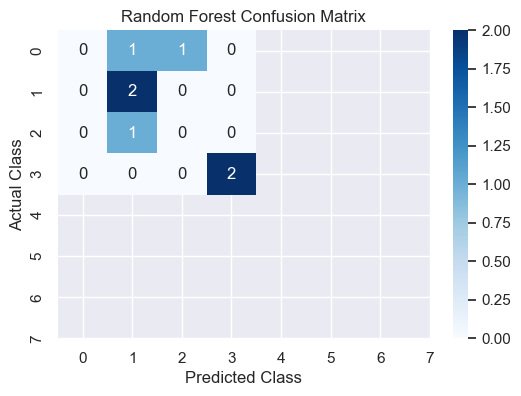

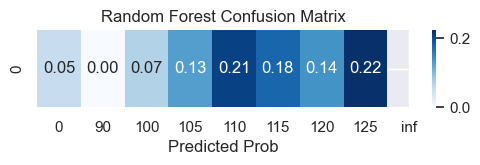

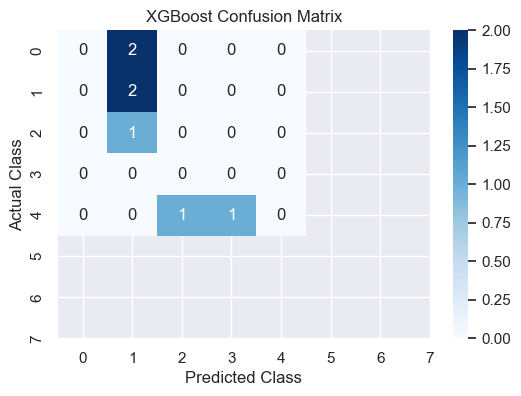

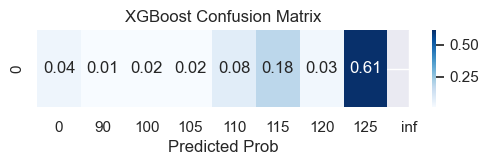

In [47]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=bins)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [48]:
target = "Opp_PTS_C"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

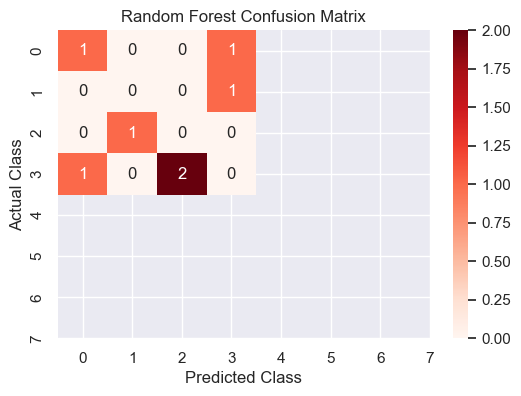

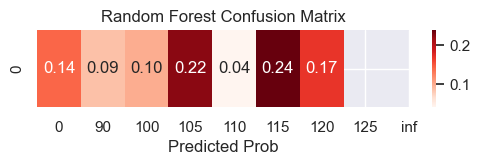

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2 3 4 5 6], got [1 2 3 4 5 6 7]

In [52]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=bins)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [53]:
target = "Tm_PTS_C"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [54]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [55]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

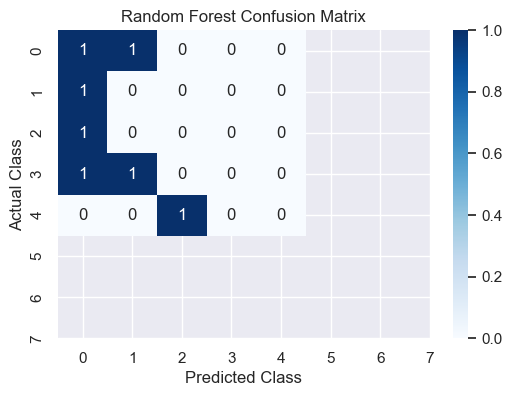

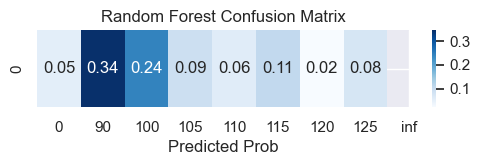

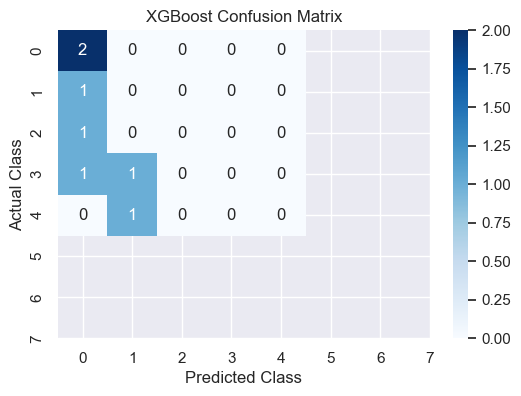

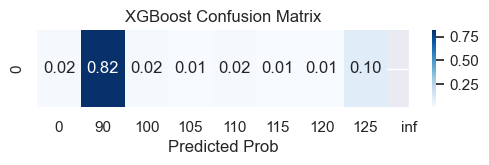

In [56]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=bins)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [57]:
target = "Opp_PTS_C"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [58]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [59]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

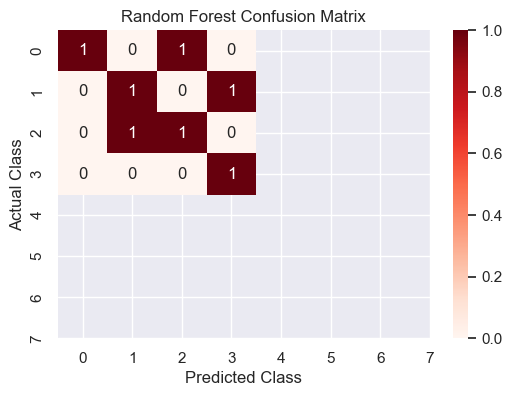

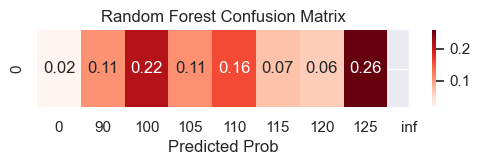

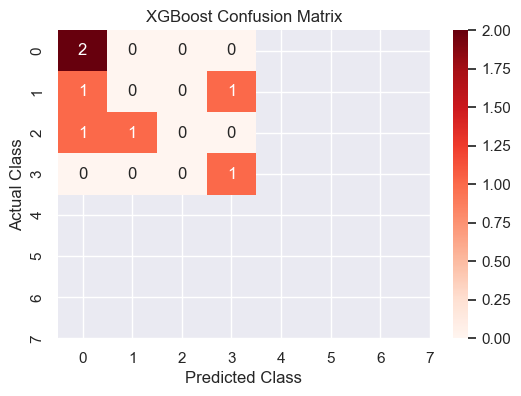

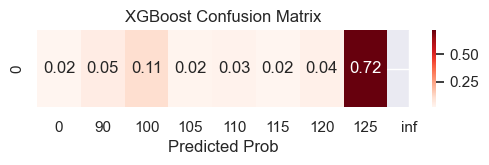

In [60]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=bins)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

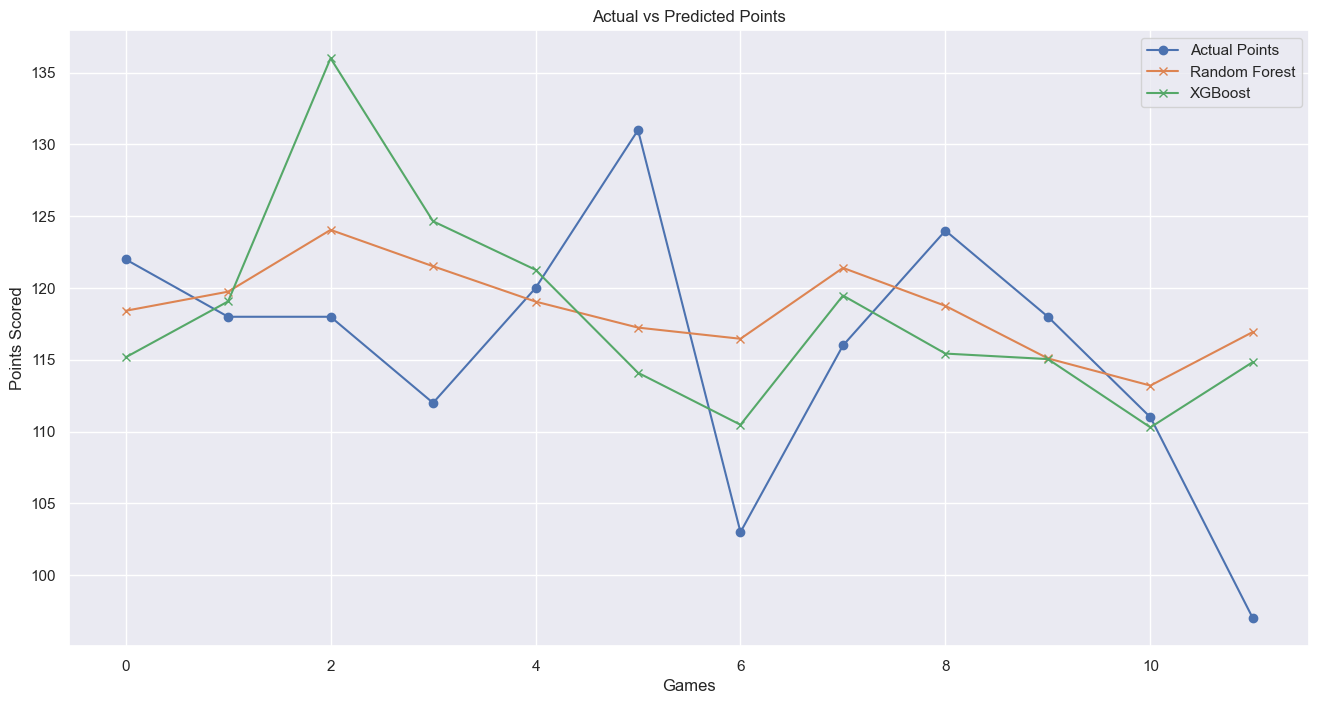

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
